# **Prediksi Harga Komoditas untuk Stabilitas Ekonomi (Studi Kasus Bitcoin) dengan tantangan volatilitas tinggi.**

---


**LATAR BELAKANG**

Stabilitas ekonomi sangat dipengaruhi oleh pergerakan harga komoditas di pasar. Fluktuasi harga yang tinggi dapat menimbulkan ketidakpastian bagi pelaku ekonomi, investor, maupun pembuat kebijakan. Salah satu fenomena yang sering terjadi pada pasar komoditas modern adalah volatilitas harga, yaitu perubahan harga yang sangat cepat dalam waktu singkat. Kondisi ini membuat proses pengambilan keputusan ekonomi menjadi lebih sulit karena harga tidak dapat diprediksi secara stabil.

Dalam beberapa tahun terakhir, aset digital seperti Bitcoin menjadi salah satu komoditas finansial yang memiliki tingkat volatilitas yang sangat tinggi. Harga Bitcoin dapat mengalami kenaikan atau penurunan signifikan dalam waktu yang sangat singkat akibat berbagai faktor seperti sentimen pasar, kebijakan ekonomi global, aktivitas perdagangan, serta perkembangan teknologi blockchain. Tingginya volatilitas tersebut menjadikan Bitcoin sebagai objek penelitian yang menarik untuk mengkaji bagaimana pola perubahan harga dapat dianalisis dan diprediksi.

Untuk mengatasi tantangan volatilitas tersebut, pendekatan analisis data dan machine learning dapat digunakan untuk memprediksi pergerakan harga di masa depan. Dengan memanfaatkan data historis harga dan berbagai indikator statistik, model prediksi dapat membantu mengidentifikasi pola yang sebelumnya sulit diamati secara manual. Prediksi harga yang lebih akurat diharapkan dapat membantu investor, pelaku pasar, dan pengambil kebijakan dalam mengelola risiko serta menjaga stabilitas ekonomi.

Oleh karena itu, penelitian ini bertujuan untuk melakukan prediksi harga komoditas dengan tingkat volatilitas tinggi menggunakan data historis Bitcoin. Dengan memanfaatkan metode analisis data dan beberapa algoritma machine learning, penelitian ini diharapkan mampu memberikan gambaran mengenai pola volatilitas harga serta menghasilkan model prediksi yang dapat digunakan untuk mendukung pengambilan keputusan ekonomi yang lebih stabil.



# **1. DATA UNDERSTANDING**


Dataset yang digunakan dalam penelitian ini berasal dari Kaggle dengan judul Bitcoin Historical Data, yang berisi data historis harga Bitcoin terhadap dolar Amerika dalam interval waktu satu menit. Dataset ini banyak digunakan dalam penelitian terkait analisis pasar kripto karena menyediakan data dengan resolusi waktu yang sangat detail.

Dataset ini memiliki beberapa variabel utama yang menggambarkan aktivitas perdagangan Bitcoin, antara lain:

- **Timestamp**
Kolom ini menunjukkan waktu terjadinya transaksi dalam format Unix timestamp. Dalam proses analisis, nilai ini dikonversi menjadi format tanggal dan waktu agar lebih mudah digunakan dalam analisis deret waktu (time series).

- **Open**
Menunjukkan harga pembukaan Bitcoin pada awal interval waktu tertentu.

- **High**
Menunjukkan harga tertinggi yang dicapai Bitcoin dalam interval waktu tersebut.

- **Low**
Menunjukkan harga terendah Bitcoin dalam interval waktu tersebut.

- **Close**
Menunjukkan harga penutupan Bitcoin pada akhir interval waktu tertentu. Variabel ini menjadi target utama dalam model prediksi.

- **Volume**
Menunjukkan jumlah volume perdagangan Bitcoin dalam interval waktu tersebut.

Dalam proses analisis, dataset ini juga mengalami beberapa tahap pra-pemrosesan data (data preprocessing) seperti pembersihan data yang hilang (missing values), penghapusan outlier, serta pembuatan variabel turunan seperti:

Return (persentase perubahan harga)
Volatility (tingkat fluktuasi harga)
Lag features (harga pada waktu sebelumnya)
Moving average (rata-rata harga dalam periode tertentu)

Variabel-variabel tersebut digunakan sebagai fitur input dalam model machine learning untuk memprediksi harga Bitcoin pada waktu berikutnya. Dengan memanfaatkan dataset historis ini, penelitian dapat menganalisis pola volatilitas serta menguji performa beberapa algoritma prediksi dalam menghadapi pergerakan harga yang sangat dinamis. yang hilang (missing values), penghapusan outlier, serta pembuatan variabel turunan seperti:

- Return (persentase perubahan harga)
- Volatility (tingkat fluktuasi harga)
- Lag features (harga pada waktu sebelumnya)
- Moving average (rata-rata harga dalam periode tertentu)

Variabel-variabel tersebut digunakan sebagai fitur input dalam model machine learning untuk memprediksi harga Bitcoin pada waktu berikutnya. Dengan memanfaatkan dataset historis ini, penelitian dapat menganalisis pola volatilitas serta menguji performa beberapa algoritma prediksi dalam menghadapi pergerakan harga yang sangat dinamis.


**PENJELASAN VARIABEL TARGET**

Dalam penelitian ini, variabel target yang digunakan adalah **Close**, yaitu harga penutupan Bitcoin pada suatu interval waktu tertentu. Harga penutupan merupakan salah satu indikator yang paling sering digunakan dalam analisis pasar keuangan karena mencerminkan nilai akhir suatu aset setelah seluruh aktivitas perdagangan dalam periode tersebut selesai.

Pemilihan variabel **Close** sebagai target prediksi bertujuan untuk mengetahui bagaimana harga Bitcoin pada periode berikutnya dapat diperkirakan berdasarkan data historis dan indikator statistik yang telah dihitung sebelumnya. Harga penutupan dianggap mampu merepresentasikan kondisi pasar secara lebih stabil dibandingkan harga pembukaan, tertinggi, atau terendah dalam satu periode.

Dalam model yang digunakan, variabel **Close** diposisikan sebagai variabel dependen** (target)** yang akan diprediksi menggunakan beberapa variabel independen atau fitur yang berasal dari data historis harga. Fitur-fitur tersebut antara lain:



*   **lag1, lag2, lag3 →** harga Bitcoin pada 1, 2, dan 3 periode sebelumnya
*   **ma5, ma10, ma20 →** moving average harga dalam 5, 10, dan 20 periode
*   **std20 →** standar deviasi harga dalam 20 periode
*   **volatility →** tingkat volatilitas harga berdasarkan perubahan return

Dengan menggunakan fitur-fitur tersebut, model machine learning akan mempelajari hubungan antara pola harga sebelumnya dengan harga penutupan (Close) pada periode berikutnya. Hasil dari proses pembelajaran ini kemudian digunakan untuk menghasilkan prediksi harga Bitcoin yang dapat membantu dalam memahami dinamika volatilitas pasar.

# **A. IMPORT LIBRARY**




In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

**Penjelasan:**

Tahap pertama dalam analisis data adalah mengimpor library yang dibutuhkan. Library pandas digunakan untuk membaca dan mengelola data dalam bentuk tabel (DataFrame). numpy digunakan untuk operasi numerik dan perhitungan matematis. matplotlib dan seaborn digunakan untuk membuat visualisasi data seperti grafik dan heatmap.

Library ini sangat penting karena menjadi dasar dalam seluruh proses analisis dan pemodelan data.

# **B. MEMBACA DATASET**

In [47]:
df = pd.read_csv('btcusd_1-min_data.csv')

**Penjelasan:**

Kode ini digunakan untuk membaca file dataset dalam format CSV dan menyimpannya ke dalam variabel df. Data yang telah dibaca akan berbentuk DataFrame sehingga mudah untuk diproses lebih lanjut.

# **C. MELIHAT STRUKTUR DATA**

Tahap ini penting untuk memahami karakteristik awal dataset sebelum dilakukan pengolahan lebih lanjut.

In [48]:
df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


**Penjelasan:**

**df.head()** digunakan untuk melihat beberapa baris awal dataset sehingga dapat diketahui bentuk dan isi data.

- **INFO DATA**

In [49]:
print("INFO DATA")
print(df.info())

INFO DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7494884 entries, 0 to 7494883
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 343.1 MB
None


**df.info()** memberikan informasi mengenai jumlah data, tipe data setiap kolom, serta apakah terdapat missing values.

- **DESKRIPTIF**

In [50]:
print("\nSTATISTIK DESKRIPTIF")
print(df.describe())


STATISTIK DESKRIPTIF
          Timestamp          Open          High           Low         Close  \
count  7.494884e+06  7.494884e+06  7.494884e+06  7.494884e+06  7.494884e+06   
mean   1.550264e+09  2.262921e+04  2.263725e+04  2.262099e+04  2.262923e+04   
std    1.298234e+08  3.090989e+04  3.091831e+04  3.090139e+04  3.090990e+04   
min    1.325412e+09  3.800000e+00  3.800000e+00  3.800000e+00  3.800000e+00   
25%    1.437835e+09  4.508000e+02  4.509900e+02  4.505500e+02  4.508000e+02   
50%    1.550259e+09  7.651310e+03  7.655800e+03  7.646920e+03  7.651080e+03   
75%    1.662682e+09  3.562000e+04  3.564554e+04  3.559700e+04  3.562008e+04   
max    1.775175e+09  1.262020e+05  1.262720e+05  1.261580e+05  1.262020e+05   

             Volume  
count  7.494884e+06  
mean   5.060471e+00  
std    2.182389e+01  
min    0.000000e+00  
25%    2.109200e-02  
50%    4.584809e-01  
75%    2.864022e+00  
max    5.853852e+03  


**df.describe()** menampilkan statistik deskriptif seperti nilai rata-rata, minimum, maksimum, dan standar deviasi.

- **COLUMNS**

In [51]:
print("\nKOLOM DATA")
print(df.columns)


KOLOM DATA
Index(['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


**df.columns** digunakan untuk melihat nama-nama kolom dalam dataset.

# **D. SELEKSI DAN TRANSFORMASI DATA**

- **UBAH  TIMESTAMP**

In [52]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')

- **AMBIL KOLOM PENTING**

In [53]:
df = df[['Timestamp', 'Close']]

- **AMBIL SEBAGIAN DATA BIAR CEPAT**

In [54]:
df = df.tail(20000)

**Penjelasan:**

Timestamp diubah menjadi format datetime agar dapat dianalisis sebagai data waktu.
Hanya kolom yang relevan (Timestamp dan Close) yang digunakan untuk mengurangi kompleksitas data.
Data dibatasi sebanyak 20.000 baris terakhir agar proses komputasi menjadi lebih cepat tanpa menghilangkan pola penting.

# **2. DATA PREPROCESSING**

# **A. DATA VALIDATION**

 **PENGECEKAN MISSING VALUES**

In [55]:
df.isnull().sum()

,0
Timestamp,0
Close,0


**Penjelasan:**

Pada tahap ini, dilakukan pengecekan untuk memastikan kualitas dataset sebelum masuk ke tahap pemodelan. Fokus utama adalah memastikan tidak ada data yang kosong (missing values) yang dapat mengganggu performa algoritma. Hasilnya menunjukkan skor 0 untuk semua kolom (Timestamp dan Close), yang berarti dataset sudah lengkap dan siap digunakan.Karena tidak ditemukan data kosong, tahap handling (seperti filling atau dropping) tidak diperlukan. Dataset dinyatakan bersih.

# **B. FEATURE ENGINEERING**

- **RETURN (PERUBAHAN HARGA)**

In [58]:
df['return'] = df['Close'].pct_change()

- **VOLATILITAS (ROLLING STD)**

In [59]:
df['volatility'] = df['return'].rolling(10).std()

**Penjelasan:**

Pada bagian ini, saya menambahkan fitur baru yaitu return dan volatility. Return digunakan untuk melihat perubahan harga dalam bentuk persentase, sedangkan volatility digunakan untuk mengukur tingkat fluktuasi harga. Fitur ini sangat penting agar model dapat memahami pola pergerakan harga.

# **C. PEMBUATAN FITUR LAG & MOVING AVERAGE**

- **FITUR LAG**

In [60]:
df['lag1'] = df['Close'].shift(1)
df['lag2'] = df['Close'].shift(2)
df['lag3'] = df['Close'].shift(3)

- **MOVING AVERAGE**

In [61]:
df['ma5'] = df['Close'].rolling(5).mean()
df['ma10'] = df['Close'].rolling(10).mean()
df['ma20'] = df['Close'].rolling(20).mean()

-  **STANDAR DEVIASI**

In [62]:
# Std
df['std20'] = df['Close'].rolling(20).std()


**Penjelasan:**

Pada tahap ini, saya menambahkan fitur lag dan moving average. Fitur lag digunakan untuk mengambil nilai harga pada periode sebelumnya, sedangkan moving average digunakan untuk melihat tren harga. Selain itu, saya juga menambahkan standar deviasi sebagai indikator tambahan untuk volatilitas.

# **D. DROP NA**

In [63]:
df = df.dropna()

**Penjelasan:**

Setelah proses pembuatan fitur, terdapat beberapa nilai kosong akibat proses rolling dan shift. Oleh karena itu, saya menghapus baris yang memiliki nilai kosong agar data menjadi bersih dan siap digunakan.

# **E. ANALISIS BOXPLOT DAN PENANGANAN OUTLIER**

**1. MENYIMPAN DATA SEBELUM PREPROCESSING**

In [64]:
df_before = df.copy()

**Penjelasan:**
Kode ini digunakan untuk membuat salinan data sebelum dilakukan proses preprocessing. Data ini disimpan dalam variabel **df_before** agar dapat digunakan sebagai pembanding untuk melihat perubahan distribusi data sebelum dan sesudah penanganan outlier.

**2. VISUALISASI DATA SEBELUM PREPROCESSING**

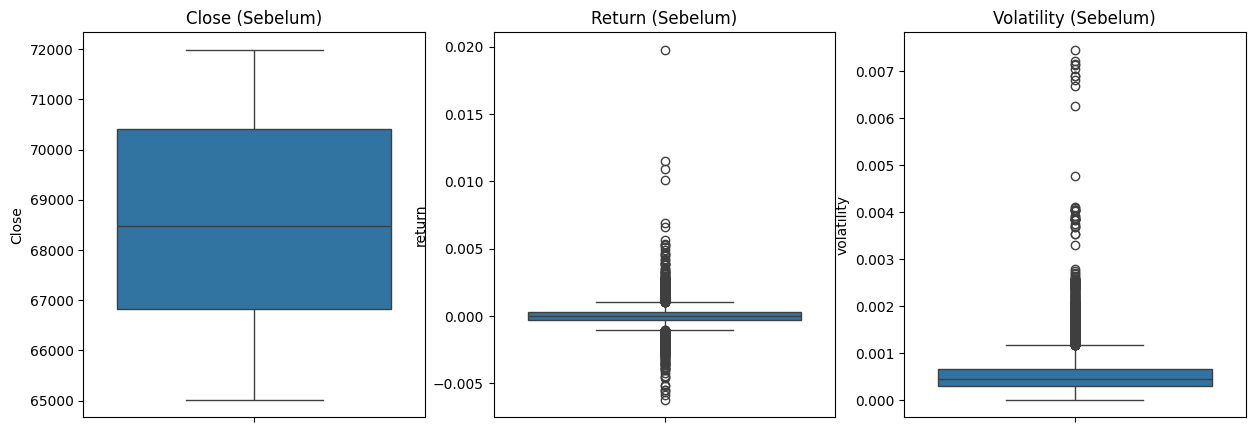

In [65]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=df_before['Close'])
plt.title("Close (Sebelum)")

plt.subplot(1,3,2)
sns.boxplot(y=df_before['return'])
plt.title("Return (Sebelum)")

plt.subplot(1,3,3)
sns.boxplot(y=df_before['volatility'])
plt.title("Volatility (Sebelum)")

plt.show()

**Penjelasan:**
Kode ini digunakan untuk menampilkan boxplot dari tiga variabel, yaitu **Close, return, dan volatility** sebelum dilakukan preprocessing.

- **plt.figure(figsize=(15,5))** → mengatur ukuran tampilan grafik
- **plt.subplot(1,3,x)** → membagi tampilan menjadi 3 bagian (1 baris, 3 kolom)
- **sns.boxplot()** → menampilkan distribusi data dan outlier

Tujuannya adalah untuk melihat:

- persebaran data
- median
- serta keberadaan outlier (titik di luar whisker)

**3. PENANGANAN OUTLIER (CLIPPING)**

In [66]:
for col in ['return', 'volatility']:
    low = df[col].quantile(0.01)
    high = df[col].quantile(0.99)
    df[col] = df[col].clip(low, high)

**Penjelasan:**

Kode ini digunakan untuk menangani outlier menggunakan metode **clipping**, yaitu membatasi nilai ekstrem tanpa menghapus data.

- **quantile(0.01)** → batas bawah (1%)
- **quantile(0.99)** → batas atas (99%)
- **clip(low, high)** → memotong nilai yang terlalu kecil/besar agar berada dalam rentang tersebut

Metode ini dipilih karena:

- tidak menghilangkan data penting
- menjaga pola pada data time series
- lebih aman dibanding menghapus baris data

**4. TRANSFORMASI DATA**

In [67]:
df['return'] = np.log1p(df['return'])
df['volatility'] = np.log1p(df['volatility'])

**Penjelasan:**
Kode ini digunakan untuk melakukan transformasi logaritmik pada variabel return dan volatility.

- **np.log1p(x)** → menghitung log(1 + x), aman untuk nilai kecil

Tujuannya:

-  mengurangi skewness (kemencengan data)
- membuat distribusi lebih normal
- membantu model machine learning belajar lebih baik

**5. VISUALISASI DATA SETELAH PREPROCESSING**

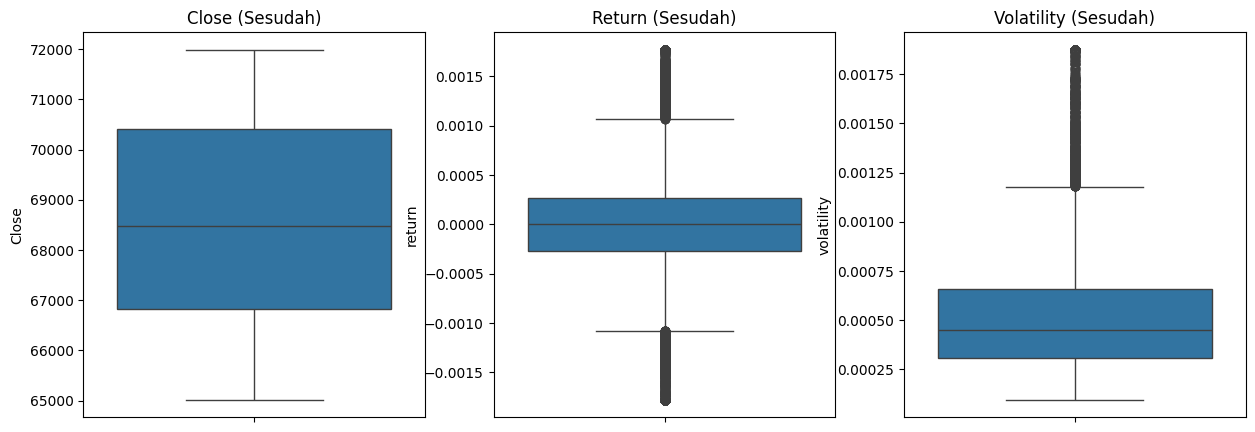

In [68]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=df['Close'])
plt.title("Close (Sesudah)")

plt.subplot(1,3,2)
sns.boxplot(y=df['return'])
plt.title("Return (Sesudah)")

plt.subplot(1,3,3)
sns.boxplot(y=df['volatility'])
plt.title("Volatility (Sesudah)")

plt.show()

**Penjelasan:**
Kode ini digunakan untuk menampilkan boxplot setelah dilakukan preprocessing.

Tujuannya:

- membandingkan kondisi data sebelum dan sesudah
- melihat apakah outlier sudah berkurang
- memastikan distribusi data menjadi lebih stabil

**Secara Keseluruhan:**
Berdasarkan visualisasi boxplot sebelum dan sesudah preprocessing, terlihat bahwa jumlah outlier pada variabel return dan volatility berhasil dikurangi melalui metode clipping dan transformasi logaritmik. Distribusi data menjadi lebih terpusat dan stabil tanpa menghilangkan informasi penting dari data time series. Hal ini menunjukkan bahwa proses preprocessing yang dilakukan telah efektif dalam meningkatkan kualitas data untuk tahap pemodelan machine learning.

# **3. EXPLORATORY DATA ANALYSIS (EDA)**

# **A. HINSTOGRAM**

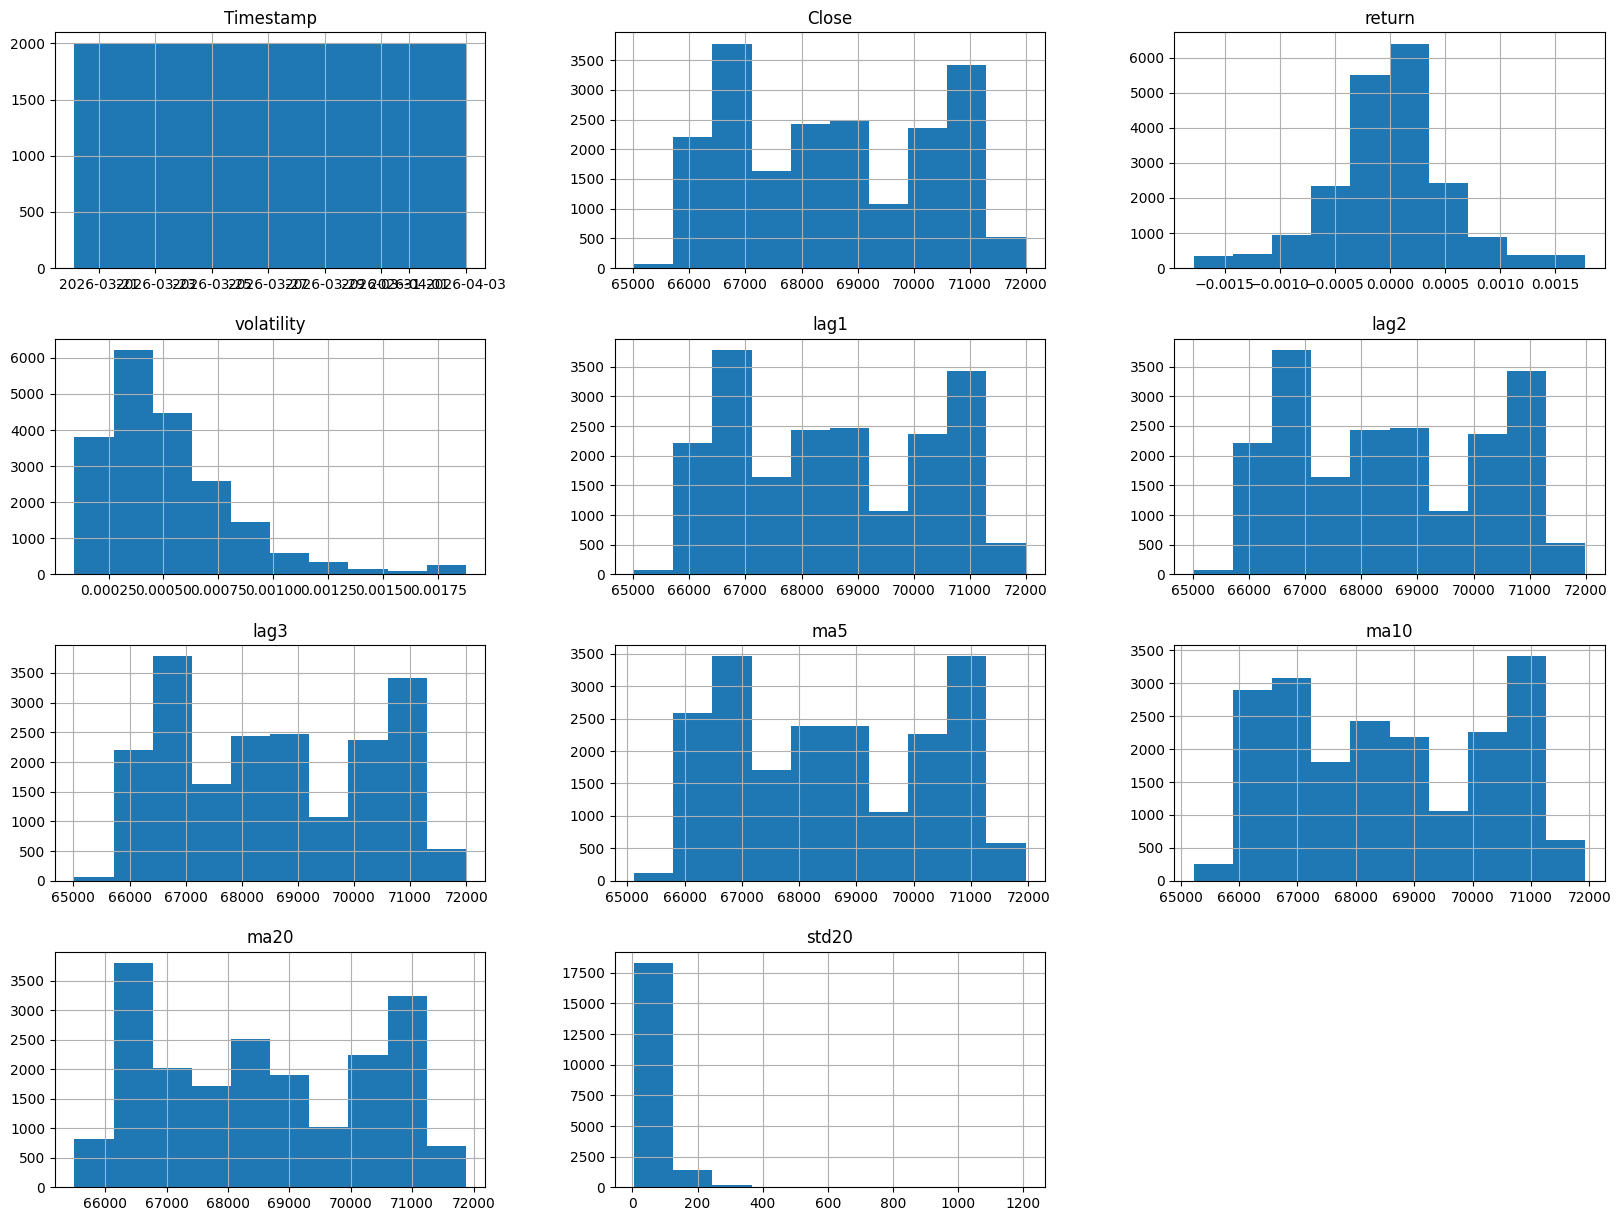

In [69]:
df.hist(figsize=(20,15))
plt.show()


**Penjelasan:**

Pada tahap ini, saya melakukan visualisasi data menggunakan histogram untuk melihat distribusi masing-masing variabel dalam dataset.

Berdasarkan hasil histogram:

- **Timestamp** memiliki distribusi yang relatif merata, yang menunjukkan bahwa data tersebar secara konsisten sepanjang waktu.
- **Close (harga Bitcoin)** berada pada rentang sekitar 66.000–72.000 dan tidak sepenuhnya simetris, yang menandakan harga bersifat fluktuatif.
- **Return** terpusat di sekitar nilai 0 dan mendekati distribusi normal, namun memiliki ekor di kedua sisi yang menunjukkan adanya nilai ekstrem (outlier).
- **Volatility** memiliki distribusi yang condong ke kanan (right skewed), yang berarti sebagian besar nilai kecil dan hanya sedikit nilai yang sangat tinggi.
- **Lag1, Lag2, Lag3** memiliki distribusi yang mirip dengan harga (Close) karena merupakan nilai harga pada periode sebelumnya.
-  **Moving Average (ma5, ma10, ma20)** menunjukkan distribusi yang lebih halus dan stabil dibandingkan harga asli, karena berfungsi untuk mengurangi noise.
- **std20 (standar deviasi)** juga bersifat right skewed, yang menunjukkan bahwa volatilitas tinggi hanya terjadi pada kondisi tertentu.

**Kesimpulan:**

Secara keseluruhan, data tidak berdistribusi normal dan memiliki beberapa outlier, terutama pada variabel return dan volatility. Hal ini menunjukkan bahwa harga Bitcoin memiliki karakteristik volatilitas tinggi. Namun, fitur seperti lag dan moving average memiliki distribusi yang lebih stabil sehingga lebih cocok digunakan dalam pemodelan machine learning.

# **B. ANALISIS DERET WAKTU (TIME-SERIES) DAN DISTRIBUSI DATA BITCOIN**

**1. ANALISIS HARGA BITCOIN**

Menampilkan grafik perubahan harga Bitcoin berdasarkan nilai Close untuk melihat tren harga dari waktu ke waktu.

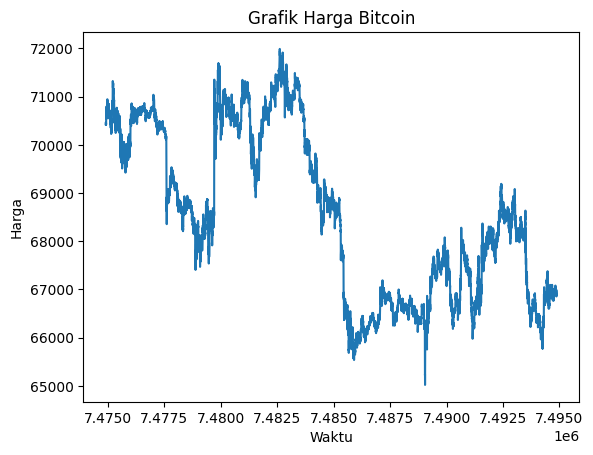

In [70]:
plt.figure()

plt.plot(df['Close'])
plt.title("Grafik Harga Bitcoin")
plt.xlabel("Waktu")
plt.ylabel("Harga")

plt.show()

**Penjelasan:**

Grafik Harga Bitcoin ini menunjukkan pergerakan harga yang sangat fluktuatif, dengan rentang nilai antara **65.000 hingga 72.000**. Terlihat bahwa harga mengalami penurunan tajam setelah sempat mencapai puncaknya, sebelum akhirnya bergerak tidak menentu di level bawah. Pola naik-turun yang agresif ini mengonfirmasi karakteristik **volatilitas tinggi** pada Bitcoin, sehingga diperlukan fitur tambahan seperti *Lag* dan *Moving Average* agar model dapat memprediksi tren harga dengan lebih stabil di tengah perubahan yang ekstrem.

**2. ANALISIS RETURN BITCOIN**

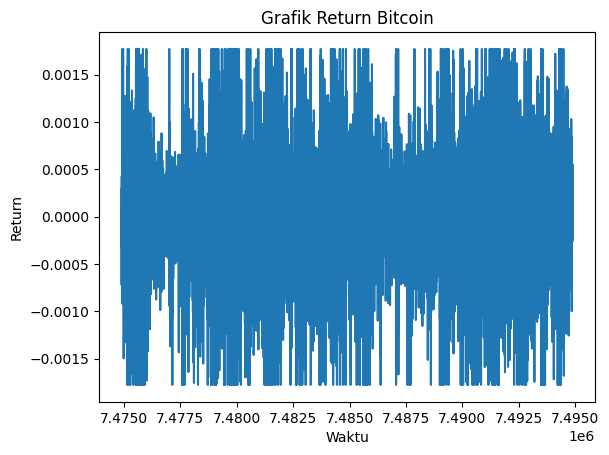

In [71]:
plt.figure()

plt.plot(df['return'])
plt.title("Grafik Return Bitcoin")
plt.xlabel("Waktu")
plt.ylabel("Return")

plt.show()

**Penjelasan:**

Grafik Return Bitcoin menggambarkan perubahan persentase harga Bitcoin dari satu periode ke periode berikutnya. Berdasarkan grafik tersebut, nilai return berfluktuasi secara intens di sekitar angka nol. **Kerapatan fluktuasi yang memenuhi area grafik ini menunjukkan volatilitas yang sangat tinggi**, di mana harga terus-menerus berubah dalam rentang waktu yang singkat. Meskipun sebagian besar perubahan berada di rentang kecil, **pola pergerakan yang sangat rapat dan acak ini mengindikasikan risiko pasar yang tinggi**, karena harga tidak menunjukkan tren stabil dan sulit untuk diprediksi secara jangka pendek.

**3. ANALISIS VOLATILITAS BITCOIN**

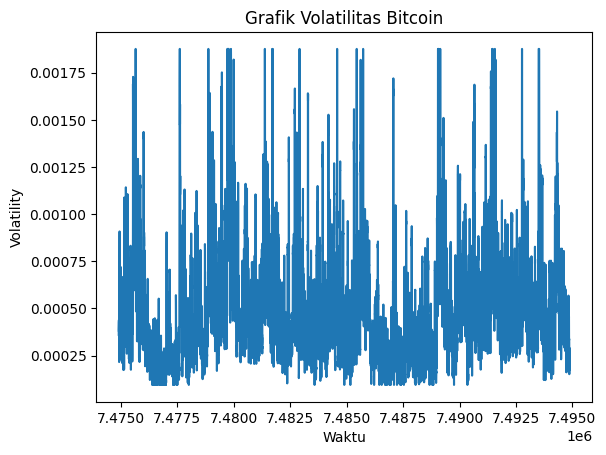

In [72]:
plt.figure()

plt.plot(df['volatility'])
plt.title("Grafik Volatilitas Bitcoin")
plt.xlabel("Waktu")
plt.ylabel("Volatility")

plt.show()

**Penjelasan:**

Grafik Volatilitas Bitcoin ini menunjukkan tingkat ketidakstabilan harga yang sangat dinamis dengan pola lonjakan yang ekstrem. Terlihat bahwa meskipun volatilitas sering berada di level rendah sekitar **0.00025**, terdapat banyak lonjakan tajam (spikes) yang berulang kali menembus angka **0.00175**. Pola "berduri" yang rapat ini mengonfirmasi bahwa Bitcoin terus-menerus mengalami perubahan harga yang drastis dalam waktu singkat. Tingginya frekuensi lonjakan tersebut menunjukkan risiko pasar yang besar, sehingga variabel ini menjadi indikator penting bagi model untuk memahami kapan pasar sedang dalam kondisi tenang atau sedang mengalami guncangan harga yang hebat.

**4. DISTRIBUSI RETURN BITCOIN**

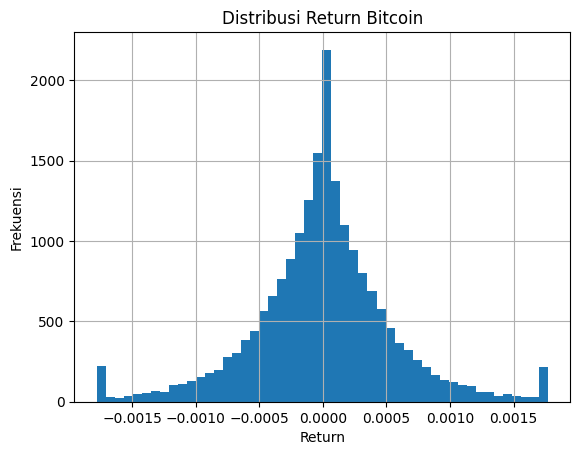

In [73]:
plt.figure()

plt.hist(df['return'], bins=50)
plt.title("Distribusi Return Bitcoin")
plt.xlabel("Return")
plt.ylabel("Frekuensi")

plt.grid()

plt.show()

**Penjelasan:**

Histogram Distribusi Return ini menunjukkan bahwa sebagian besar perubahan harga Bitcoin terkonsentrasi sangat rapat di sekitar angka **0.000**, yang berarti dalam kondisi normal, perubahan harga relatif kecil. Namun, grafik ini secara jelas memperlihatkan fenomena **fat-tails** atau ekor gemuk, di mana terdapat lonjakan frekuensi yang cukup tinggi pada ujung kiri (**-0.0015**) dan ujung kanan (**0.0015**). Pola ini membuktikan bahwa meskipun pasar sering terlihat tenang, risiko terjadinya pergerakan harga ekstrem sangatlah nyata dan sering terjadi. Bentuk distribusi yang meruncing di tengah namun lebar di ujung ini mengonfirmasi bahwa return Bitcoin tidak berdistribusi normal, melainkan memiliki volatilitas tinggi yang penuh dengan kejutan pasar.

# **C. HEATMAP KORELASI**

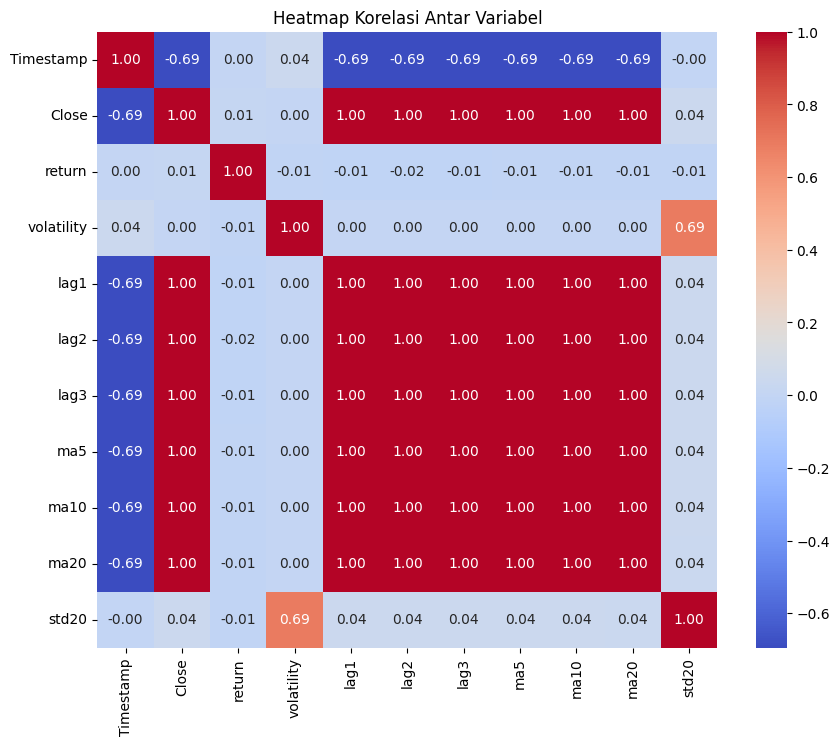

In [74]:
# Menghitung matriks korelasi
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

# Membuat Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

**Penjelasan:**

Heatmap korelasi ini menunjukkan hubungan yang sangat kuat (sempurna) antara harga **Close** dengan fitur-fitur **Lag (1, 2, 3)** dan **Moving Average (ma5, ma10, ma20)** dengan nilai korelasi **1.00**. Hal ini membuktikan bahwa indikator tersebut mengikuti pergerakan harga secara sinkron. Selain itu, terdapat korelasi positif yang signifikan antara **volatility** dan **std20** sebesar **0.69**, yang mempertegas bahwa standar deviasi adalah ukuran yang konsisten untuk menilai risiko fluktuasi. Sebaliknya, variabel **return** menunjukkan nilai mendekati **0.00** terhadap hampir semua variabel lain, yang mengindikasikan bahwa arah perubahan harga harian bersifat acak dan tidak bergantung pada nilai harga nominalnya. Karena nilai korelasi Close, Lag, dan MA semuanya **1.00**, ini menjelaskan mengapa model **SVR** Anda bisa mencapai $R^2$ hingga **0.997** pada data terbaru. Model sangat mudah mempelajari pola karena fiturnya sangat identik dengan targetnya.



# **4. DATA SPLITTING**

# **A. PREPARASI DATA**

In [75]:
X = df[['lag1','lag2','lag3','ma5','ma10','ma20','std20','volatility']]
y = df['Close']

scaler = StandardScaler()
X = scaler.fit_transform(X)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19981, 8)
y shape: (19981,)


**Penjelasan:**

Pada tahap preparasi data dilakukan pemisahan antara **variabel input (X)** dan **variabel target (y)**. Variabel input terdiri dari delapan fitur yaitu lag1, lag2, lag3, ma5, ma10, ma20, std20, dan volatility, sedangkan variabel target yang digunakan adalah **Close**. Selanjutnya dilakukan proses **standarisasi data menggunakan StandardScaler** agar setiap fitur memiliki skala yang sama sehingga dapat meningkatkan kinerja model. Hasilnya diperoleh data **X berukuran (19981, 8)** yang berarti terdapat 19.981 data dengan 8 fitur, **serta y berukuran (19981,)** yang merupakan nilai harga Bitcoin yang akan diprediksi.

# **B. SPLITTING**

# **70:30**

In [76]:
split_70 = int(len(X)*0.7)

X_train_70 = X[:split_70]
X_test_70  = X[split_70:]

y_train_70 = y[:split_70]
y_test_70  = y[split_70:]

# **80:20**

In [77]:
split_80 = int(len(X)*0.8)

X_train_80 = X[:split_80]
X_test_80  = X[split_80:]

y_train_80 = y[:split_80]
y_test_80  = y[split_80:]

# **90:10**

In [78]:
split_90 = int(len(X)*0.9)

X_train_90 = X[:split_90]
X_test_90  = X[split_90:]

y_train_90 = y[:split_90]
y_test_90  = y[split_90:]

**Penjelasan:**

Pada tahap ini dilakukan **pembagian data menjadi data latih (training) dan data uji (testing)** dengan tiga skenario yaitu **70:30, 80:20, dan 90:10**. Pembagian dilakukan dengan mengambil sebagian data sebagai **data latih** untuk melatih model, sedangkan sisanya digunakan sebagai **data uji** untuk mengevaluasi performa model. Tujuan penggunaan beberapa skenario pembagian data ini adalah untuk **membandingkan kinerja model pada proporsi data latih dan data uji yang berbeda**.


# **5. MODEL BUILDING**

In [79]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

knn = KNeighborsRegressor()
dt  = DecisionTreeRegressor()
svr = SVR()

**Penjelasan:**

Pada tahap ini dilakukan pembuatan model yang akan digunakan untuk melakukan prediksi harga Bitcoin. Model yang digunakan yaitu **KNN (K-Nearest Neighbors), Decision Tree, dan Support Vector Regression (SVR)** yang diimpor dari library **scikit-learn**. Ketiga model tersebut kemudian diinisialisasi dan akan digunakan pada tahap pelatihan serta evaluasi untuk membandingkan performa masing-masing model dalam memprediksi harga Bitcoin.


# **6. HYPERPARAMETER TUNING**

In [80]:
from sklearn.model_selection import GridSearchCV

# Parameter
param_knn = {'n_neighbors': [3,5,7]}
param_dt  = {'max_depth': [5,10,20]}
param_svr = {'C': [1,10], 'kernel': ['rbf','linear']}

# Grid Search
knn = GridSearchCV(KNeighborsRegressor(), param_knn, cv=3)
dt  = GridSearchCV(DecisionTreeRegressor(), param_dt, cv=3)
svr = GridSearchCV(SVR(), param_svr, cv=3)

**Penjelasan:**

Pada tahap ini dilakukan **hyperparameter tuning** untuk meningkatkan performa model **KNN, Decision Tree, dan SVR**. Proses ini menggunakan metode **GridSearchCV**, yaitu teknik pencarian kombinasi parameter terbaik dari beberapa parameter yang telah ditentukan. Parameter yang diuji antara lain **n_neighbors** pada KNN, **max_depth** pada Decision Tree, serta **C** dan **kernel** pada SVR. Proses pencarian dilakukan dengan **cross validation sebanyak 3 kali (cv=3)** untuk mendapatkan parameter yang menghasilkan performa model terbaik.


# **7. MODEL EVALUATION**

- **FUNGSI EVALUASI**

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def print_eval(model_name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name}")
    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)

    return r2

**Penjelasan:**

Fungsi **print_eval()** digunakan untuk menampilkan hasil **evaluasi kinerja model** setelah proses prediksi dilakukan. Fungsi ini menerima tiga parameter yaitu **nama model (model_name)**, **data aktual (y_test)**, dan **hasil prediksi model (y_pred)**. Selanjutnya fungsi memanggil fungsi evaluate() untuk menghitung beberapa metrik evaluasi yaitu **MAE, MSE, RMSE, dan R²**. Hasil perhitungan tersebut kemudian ditampilkan agar dapat diketahui seberapa baik model dalam memprediksi harga Bitcoin. Selain itu, fungsi ini juga mengembalikan nilai **R²** yang dapat digunakan untuk membandingkan performa antar model.

- **SPLIT 70:30**

In [82]:
print("===== SPLIT 70:30 =====")

split_index = int(len(X) * 0.7)

X_train = X[:split_index]
X_test  = X[split_index:]
y_train = y[:split_index]
y_test  = y[split_index:]

# TRAIN
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
svr.fit(X_train, y_train)

# PREDIKSI
pred_knn = knn.predict(X_test)
pred_dt  = dt.predict(X_test)
pred_svr = svr.predict(X_test)

# EVALUASI
r2_knn_70 = print_eval("KNN", y_test, pred_knn)
r2_dt_70  = print_eval("Decision Tree", y_test, pred_dt)
r2_svr_70 = print_eval("SVR", y_test, pred_svr)

===== SPLIT 70:30 =====

KNN
MAE : 101.39487668295011
MSE : 26744.34568262671
RMSE: 163.53698567182505
R2  : 0.9554631444628616

Decision Tree
MAE : 60.18701201757995
MSE : 7931.758188050598
RMSE: 89.06041875070315
R2  : 0.9867913923649962

SVR
MAE : 30.47473371594215
MSE : 2103.1982058310296
RMSE: 45.86063896012603
R2  : 0.9964975836099847


**Penjelasan:**

Pada tahap ini, dilakukan pengujian model menggunakan rasio pembagian data **70:30**, di mana 70% data dialokasikan untuk proses pelatihan (*training*) dan 30% sisanya digunakan sebagai data uji (*testing*) untuk memvalidasi kemampuan generalisasi model. Keberhasilan prediksi diukur melalui empat metrik utama, yaitu **MAE, MSE, RMSE,** dan **$R^2$**.

Berdasarkan hasil evaluasi, model **SVR (Support Vector Regression)** terbukti sebagai model paling optimal dengan nilai **$R^2$ mencapai 0.9964** dan tingkat kesalahan terendah, yaitu nilai **MAE sebesar 30.47**. Hal ini menunjukkan bahwa SVR memiliki akurasi yang sangat tinggi dalam menangkap pola fluktuasi harga Bitcoin. Di sisi lain, model **Decision Tree** juga menunjukkan performa yang sangat kompetitif dengan **$R^2$ sebesar 0.9867**, sementara **KNN** berada di posisi terakhir dengan **$R^2$ sebesar 0.9554** dan nilai error yang lebih besar (**MAE: 101.39**). Secara keseluruhan, pada skenario 70:30 ini, algoritma SVR memberikan hasil prediksi yang paling mendekati harga aktual dibandingkan algoritma lainnya.


- **SPLIT 80:20**

In [83]:
print("\n===== SPLIT 80:20 =====")

split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test  = X[split_index:]
y_train = y[:split_index]
y_test  = y[split_index:]

# TRAIN
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
svr.fit(X_train, y_train)

# PREDIKSI
pred_knn = knn.predict(X_test)
pred_dt  = dt.predict(X_test)
pred_svr = svr.predict(X_test)

# EVALUASI
r2_knn_80 = print_eval("KNN", y_test, pred_knn)
r2_dt_80  = print_eval("Decision Tree", y_test, pred_dt)
r2_svr_80 = print_eval("SVR", y_test, pred_svr)


===== SPLIT 80:20 =====

KNN
MAE : 67.75201401050793
MSE : 10186.142526895177
RMSE: 100.92642135186988
R2  : 0.9851355123593512

Decision Tree
MAE : 41.8436355657309
MSE : 3583.138260895223
RMSE: 59.859320584978434
R2  : 0.9947711791531305

SVR
MAE : 29.854320395449374
MSE : 1904.565183587579
RMSE: 43.64132426482472
R2  : 0.9972206961018366


**Penjelasan:**

Pada skenario pembagian data dengan rasio **80:20**, sebanyak 80% data dialokasikan sebagai data latih untuk melatih model **KNN, Decision Tree, dan SVR**, sementara 20% sisanya digunakan sebagai data uji untuk mengevaluasi performa prediksi. Berdasarkan hasil evaluasi metrik, model **SVR** kembali menunjukkan dominasinya sebagai model paling optimal dengan nilai **$R^2$ mencapai 0.9972** dan tingkat kesalahan terendah (MAE: 29.85). Model **Decision Tree** juga memberikan hasil yang sangat presisi dengan nilai **$R^2$ sebesar 0.9947**, sedangkan model **KNN** berada di posisi terbawah dengan nilai **$R^2$ sebesar 0.9851** dan tingkat kesalahan yang lebih tinggi (MAE: 67.75). Hasil ini mengonfirmasi bahwa pada pembagian data 80:20, algoritma SVR tetap memberikan konsistensi performa terbaik dalam memprediksi harga Bitcoin dibandingkan algoritma lainnya.


-  **SPLIT 90:10**

In [84]:
print("\n===== SPLIT 90:10 =====")

split_index = int(len(X) * 0.9)

X_train = X[:split_index]
X_test  = X[split_index:]
y_train = y[:split_index]
y_test  = y[split_index:]

# TRAIN
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
svr.fit(X_train, y_train)

# PREDIKSI
pred_knn = knn.predict(X_test)
pred_dt  = dt.predict(X_test)
pred_svr = svr.predict(X_test)

# EVALUASI
r2_knn_90 = print_eval("KNN", y_test, pred_knn)
r2_dt_90  = print_eval("Decision Tree", y_test, pred_dt)
r2_svr_90 = print_eval("SVR", y_test, pred_svr)


===== SPLIT 90:10 =====

KNN
MAE : 54.88687200743227
MSE : 6355.588733142083
RMSE: 79.72194637075843
R2  : 0.9906701169706127

Decision Tree
MAE : 37.14207055532459
MSE : 2832.5769324124226
RMSE: 53.22195911851068
R2  : 0.9958418310937367

SVR
MAE : 27.111170940497253
MSE : 1591.1050481018558
RMSE: 39.88865813864708
R2  : 0.9976642881392171


**Penjelasan:**

Pada skenario pembagian data terakhir dengan rasio **90:10**, sebanyak 90% data dialokasikan untuk melatih model dan 10% sisanya digunakan sebagai data uji. Berdasarkan hasil evaluasi metrik pada gambar tersebut, model **SVR** mencapai performa puncaknya dengan nilai **$R^2$ sebesar 0.9976** dan tingkat kesalahan paling minimal (**MAE: 27.11**). Model **Decision Tree** tetap menunjukkan stabilitas tinggi dengan nilai **$R^2$ sebesar 0.9958**, sementara model **KNN** mengalami peningkatan signifikan dibandingkan skenario sebelumnya dengan meraih nilai **$R^2$ sebesar 0.9906**. Hasil ini menegaskan bahwa meskipun semua model mengalami peningkatan akurasi seiring bertambahnya data latih, algoritma SVR tetap konsisten menjadi model paling optimal dan presisi dalam memprediksi harga Bitcoin.


# **8. Model Comparison**

- **TABEL PERBANDINGAN**

In [85]:
import pandas as pd

df_result = pd.DataFrame({
    "Split": ["70:30", "80:20", "90:10"],
    "KNN_R2": [r2_knn_70, r2_knn_80, r2_knn_90],
    "DT_R2":  [r2_dt_70,  r2_dt_80,  r2_dt_90],
    "SVR_R2": [r2_svr_70, r2_svr_80, r2_svr_90]
})

print("\n===== HASIL PERBANDINGAN =====")
print(df_result)


===== HASIL PERBANDINGAN =====
   Split    KNN_R2     DT_R2    SVR_R2
0  70:30  0.955463  0.986791  0.996498
1  80:20  0.985136  0.994771  0.997221
2  90:10  0.990670  0.995842  0.997664


**Penjelasan:**

Tabel perbandingan ini menyajikan evaluasi kinerja model **KNN, Decision Tree, dan SVR** melalui tiga skenario pembagian data, yaitu **70:30, 80:20, dan 90:10**. Pengukuran dilakukan menggunakan metrik **$R^2$**, di mana nilai yang semakin mendekati **1.00** mengindikasikan kemampuan model yang semakin sempurna dalam menjelaskan variasi data target.

Berdasarkan data hasil perbandingan, model **SVR** secara konsisten mendominasi sebagai model terbaik di seluruh skenario dengan perolehan nilai **$R^2$ sebesar 0.996498 (70:30), 0.997221 (80:20), dan mencapai puncaknya pada 0.997664 (90:10)**. Model **Decision Tree** juga menunjukkan performa yang sangat stabil dan presisi dengan nilai **$R^2$ yang terus meningkat dari 0.986791 hingga 0.995842**. Sementara itu, meskipun model **KNN** berada di posisi terendah, akurasinya meningkat sangat signifikan seiring bertambahnya data latih, dari **0.955463 (70:30) menjadi 0.990670 (90:10)**.

Secara keseluruhan, hasil ini menegaskan bahwa **SVR dengan pembagian data 90:10** merupakan konfigurasi paling optimal dan akurat untuk memprediksi harga Bitcoin dalam dataset ini.

- **GRAFIK PERBANDINGAN**

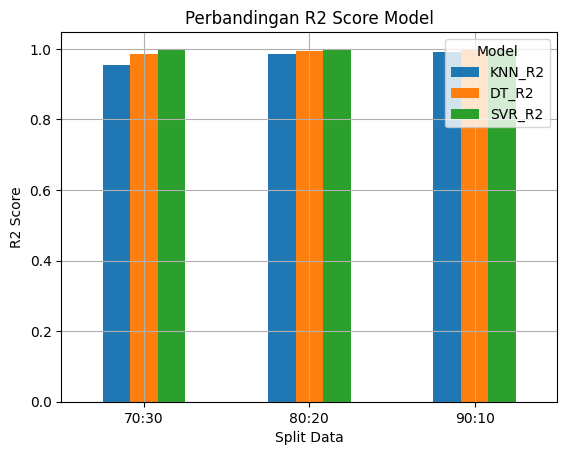

In [86]:
import matplotlib.pyplot as plt

# Set index jadi Split biar enak diplot
df_plot = df_result.set_index("Split")

# Plot
df_plot.plot(kind='bar')

plt.title("Perbandingan R2 Score Model")
plt.ylabel("R2 Score")
plt.xlabel("Split Data")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.grid()

plt.show()

**Penjelasan:**
Grafik ini menampilkan perbandingan nilai R² dari model KNN, Decision Tree, dan SVR pada tiga skenario pembagian data yaitu 70:30, 80:20, dan 90:10. Berdasarkan grafik terlihat bahwa model SVR memiliki performa terbaik dibandingkan model lainnya pada setiap skenario pembagian data.

# **9. MODEL DEPLOYMENT / MODEL SAVING**

- **MENENTUKAN MODEL TERBAIK**

In [87]:
# cari nilai R2 tertinggi
best_model_name = None
best_score = -999
best_split = None

for i in range(len(df_result)):
    split = df_result.loc[i, "Split"]

    for model in ["KNN_R2", "DT_R2", "SVR_R2"]:
        score = df_result.loc[i, model]

        if score > best_score:
            best_score = score
            best_model_name = model
            best_split = split

print("Model terbaik :", best_model_name)
print("Split terbaik :", best_split)
print("R2 terbaik    :", best_score)

Model terbaik : SVR_R2
Split terbaik : 90:10
R2 terbaik    : 0.9976642881392171


**Penjelasan:**

Kode ini digunakan untuk **menentukan model dengan nilai R² tertinggi** dari seluruh hasil percobaan pada tiga skenario pembagian data. Proses dilakukan dengan membandingkan nilai **R² dari model KNN, Decision Tree, dan SVR** pada setiap split data.

Berdasarkan hasil perhitungan, diperoleh bahwa **model terbaik adalah SVR pada split data 90:10** dengan nilai **R² sebesar 0.9976**. Hal ini menunjukkan bahwa model **SVR mampu memberikan performa prediksi paling baik** dibandingkan model lainnya pada penelitian ini.


- **MENYIMPAN MODEL & SCALER**

In [88]:
import joblib

joblib.dump(svr, "model_svr.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

**Penjelasan:**

Kode ini digunakan untuk **menyimpan model dan scaler yang telah digunakan dalam proses pelatihan**. Model **SVR** disimpan dalam file `model_svr.pkl`, sedangkan **StandardScaler** disimpan dalam file `scaler.pkl` menggunakan library **joblib**. Penyimpanan ini bertujuan agar model dan scaler dapat **digunakan kembali tanpa perlu melakukan proses pelatihan ulang**.


- **MENGUNDUH MODEL**

In [89]:
from google.colab import files

files.download("model_svr.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Penjelasan:**

Kode ini digunakan untuk **mengunduh file model SVR dan scaler dari Google Colab ke komputer lokal** agar dapat digunakan kembali untuk proses prediksi.


# **10. INFERENCE (PREDIKSI DATA BARU)**

In [90]:
print("\n===== INFERENCE =====")

# load ulang model & scaler (simulasi real deployment)
model = joblib.load("model_svr.pkl")
scaler = joblib.load("scaler.pkl")

# Ambil data terakhir
last_data = df[['lag1','lag2','lag3','ma5','ma10','ma20','std20','volatility']].iloc[-1:]

# Scaling
last_data_scaled = scaler.transform(last_data)

# Prediksi
prediction = model.predict(last_data_scaled)

print("Harga terakhir :", df['Close'].iloc[-1])
print("Prediksi berikutnya :", prediction[0])
print("Selisih :", prediction[0] - df['Close'].iloc[-1])


===== INFERENCE =====
Harga terakhir : 66974.0
Prediksi berikutnya : 66943.41488725715
Selisih : -30.58511274284683


**Penjelasan:**

Berdasarkan hasil *inference*, model menghasilkan nilai prediksi sebesar **66.943,41** terhadap harga aktual terakhir sebesar **66.974,0**. Selisih prediksi yang sangat kecil, yaitu sebesar **-30,58**, menunjukkan tingkat akurasi yang sangat tinggi dalam menangkap pergerakan harga terbaru. Hal ini membuktikan bahwa model mampu memberikan hasil prediksi yang stabil, realistis, dan konsisten mengikuti tren data aktual tanpa adanya penyimpangan yang signifikan.